## 1 - Business Understanding (Aufgabendefinition) 
- Bestimmung der betriebswirtschaftlichen Problemstellung
- Situationsbewertung
- Bestimmung analytischer Ziele
- Erstellung eines Projektplans
- ---

### Bestimmung der betriebswirtschaftlichen Problemstellung
Ein Gebrauchtwagenhändler (GWH) möchte den Preis für verfügbare Gebrauchtwagen mittels eines Modells bestimmen. Bisher wird der Preis auf Basis der Erfahrungswerte der Mitarbeiter bestimmt. Der Preis soll für die Kunden und im Vergleich zum Markt akzeptabel sein und gleichzeitig eine hohe Marge für den Händler einbringen. Durch den Einsatz einer datenbasierten Entscheidungsunterstützung soll gezeigt werden, ob es Potenzial für höhere Margen gibt. 
### Situationsbewertung
Der GWH hat Daten über verkaufte Gebrauchtwagen über die Plattform kaggle bezogen. Die Grundlage für eine Datenanalyse ist damit vorhanden. Der aktuelle Prozess ist stark von der Erfahrung der jeweiligen Mitarbeiter abhängig. Ein datenbasierter und systemgestützter Prozess könnte diese starke Abhängigkeit entlasten und die Mitarbeiter bei Ihren Entscheidungen unterstützen. Es besteht die Chance neue Erkenntnisse aus Daten zu erlangen und bisher ungenutzte Potenziale zu heben.
### Bestimmung analytischer Ziele
Identifizierung von Assoziationen in den Daten und deren Einfluss auf das Ziel-Attribut „Preis“ 
### Erstellung eines Projektplans
Zusammenstellen eines Teams (Rollen, Verantwortungen festlegen)
Vorgehen nach den CRISP-DM (Phasen und Dauer planen)
Ergebnisse dem Auftraggeber präsentieren

---

## 2 - Data Understanding (Datenverständniss)
- Daten sammeln
- Daten beschreiben
- Untersuchung der Daten
- Verifizierung der Datenqualität
- ---

### 2.1 Daten sammeln

In [1111]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Data: Based on Used Car data from https://www.kaggle.com/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/data

In [1112]:
# Import Data sets
df = pd.read_csv("toyota.csv")

### 2.2 Daten beschreiben

In [1113]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,GT86,2016,16000,Manual,24089,Petrol,265,36.2,2.0
1,GT86,2017,15995,Manual,18615,Petrol,145,36.2,2.0
2,GT86,2015,13998,Manual,27469,Petrol,265,36.2,2.0
3,GT86,2017,18998,Manual,14736,Petrol,150,36.2,2.0
4,GT86,2017,17498,Manual,36284,Petrol,145,36.2,2.0


In [1114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6738 entries, 0 to 6737
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         6738 non-null   object 
 1   year          6738 non-null   int64  
 2   price         6738 non-null   int64  
 3   transmission  6738 non-null   object 
 4   mileage       6738 non-null   int64  
 5   fuelType      6738 non-null   object 
 6   tax           6738 non-null   int64  
 7   mpg           6738 non-null   float64
 8   engineSize    6738 non-null   float64
dtypes: float64(2), int64(4), object(3)
memory usage: 473.9+ KB


In [1115]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

In [1116]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,6738.0,2016.748145,2.204062,1998.0,2016.0,2017.0,2018.00,2020.0
price,6738.0,12522.391066,6345.017587,850.0,8290.0,10795.0,14995.00,59995.0
mileage,6738.0,22857.413921,19125.464147,2.0,9446.0,18513.0,31063.75,174419.0
tax,6738.0,94.697240,73.880776,0.0,0.0,135.0,145.00,565.0
mpg,6738.0,63.042223,15.836710,2.8,55.4,62.8,69.00,235.0
engineSize,6738.0,1.471297,0.436159,0.0,1.0,1.5,1.80,4.5


In [1117]:
df.shape

(6738, 9)

### 2.3 Untersuchung der Daten (EDA)

### Univariate Analysis

In [1118]:
def skalenniveau_bestimmen(df):
    if df.dtype == 'object':  # Kategorische Daten
        # Falls es nur wenige eindeutige Werte gibt, könnte es Nominal oder Ordinal sein.
        unique_values = df.nunique()
        if unique_values <= 10:
            return "Nominal (kategorisch)"
        else:
            return "Ordinal (Reihenfolge vorhanden)"
    
    elif pd.api.types.is_numeric_dtype(df):
        if (df.min() == 0) and (df.max() > 0):  # Echte Null vorhanden (Verhältnisskala)
            return "Verhältnisskala"
        else:  # Intervalldaten
            return "Intervallskala"
    
    return "Unklar"

# Beispiel anwenden
print('model', skalenniveau_bestimmen(df['model']))  # Nominal
print('year', skalenniveau_bestimmen(df['year']))  # Verhältnisskala
print('price', skalenniveau_bestimmen(df['price']))  # Ordinal
print('transmission', skalenniveau_bestimmen(df['transmission']))  # Nominal
print('mileage', skalenniveau_bestimmen(df['mileage']))  # Verhältnisskala
print('fuelType', skalenniveau_bestimmen(df['fuelType']))  # Nominal
print('tax', skalenniveau_bestimmen(df['tax']))  # Verhältnisskala
print('mpg', skalenniveau_bestimmen(df['mpg']))  # Verhältnisskala
print('engineSize', skalenniveau_bestimmen(df['engineSize']))  # Verhältnisskala

model Ordinal (Reihenfolge vorhanden)
year Intervallskala
price Intervallskala
transmission Nominal (kategorisch)
mileage Intervallskala
fuelType Nominal (kategorisch)
tax Verhältnisskala
mpg Intervallskala
engineSize Verhältnisskala


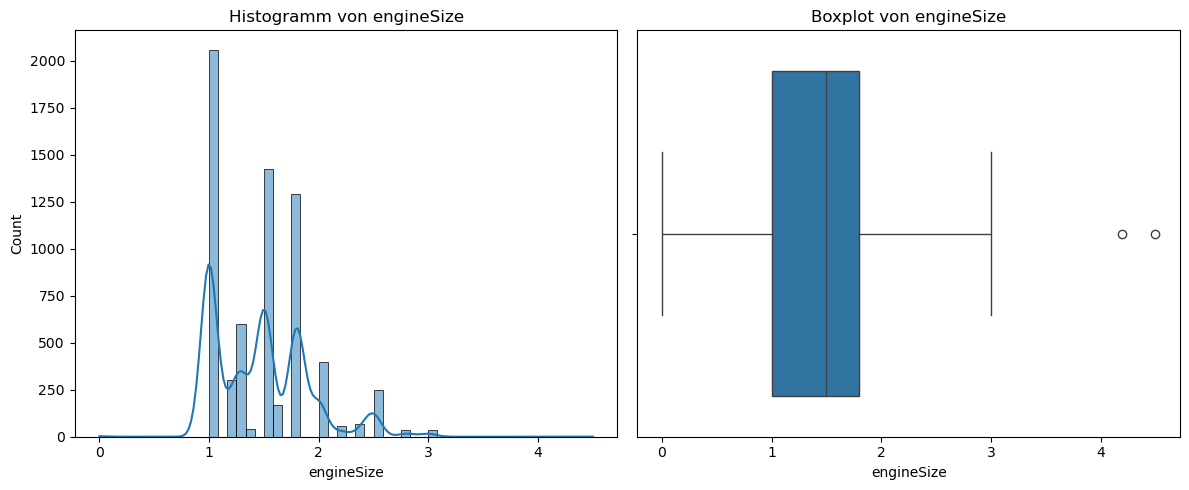

In [1119]:
# Histogramm & Boxplot for numerical variables
#num_col = "year"  
#num_col = "price" 
#num_col = "mileage"  
#num_col = "tax"  
#num_col = "mpg"  
num_col = "engineSize"

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[num_col], kde=True)
plt.title(f'Histogramm von {num_col}')

plt.subplot(1, 2, 2)
sns.boxplot(x=df[num_col])
plt.title(f'Boxplot von {num_col}')

plt.tight_layout()
plt.show()

model
Yaris            2122
Aygo             1961
Auris             712
C-HR              479
RAV4              473
Corolla           267
Prius             232
Avensis           115
Verso             114
Hilux              86
GT86               73
Land Cruiser       51
PROACE VERSO       15
Supra              12
Camry              11
IQ                  8
Urban Cruiser       4
Verso-S             3
Name: count, dtype: int64


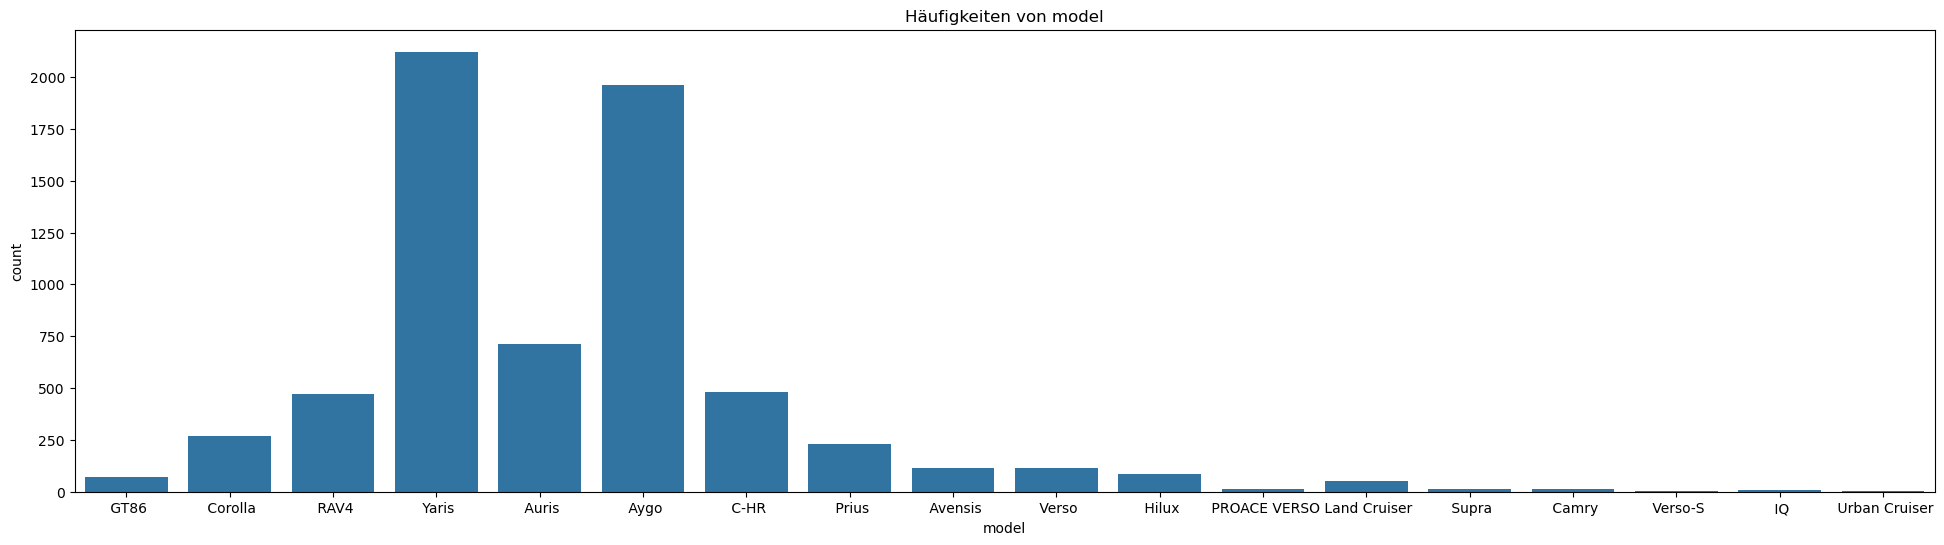

In [1120]:
# for nomminal variables
cat_col = "model"
#cat_col = "transmission" 
#cat_col = "fuelType"  

print(df[cat_col].value_counts())

# Balkendiagramm
plt.figure(figsize=(24, 6))
sns.countplot(x=df[cat_col])
plt.title(f'Häufigkeiten von {cat_col}')
plt.show()


### Bivariate Analysis

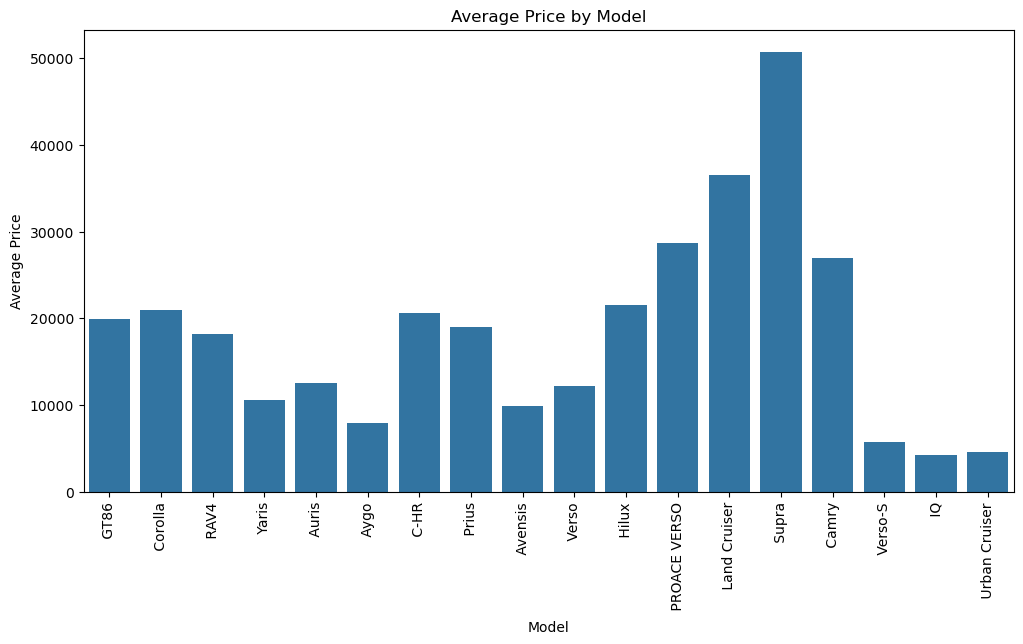

In [1121]:
plt.figure(figsize=(12, 6))
sns.barplot(x='model', y='price', data=df[:10000], errorbar=None)
plt.title('Average Price by Model')
plt.xlabel('Model')
plt.ylabel('Average Price')
plt.xticks(rotation=90)  
plt.show()

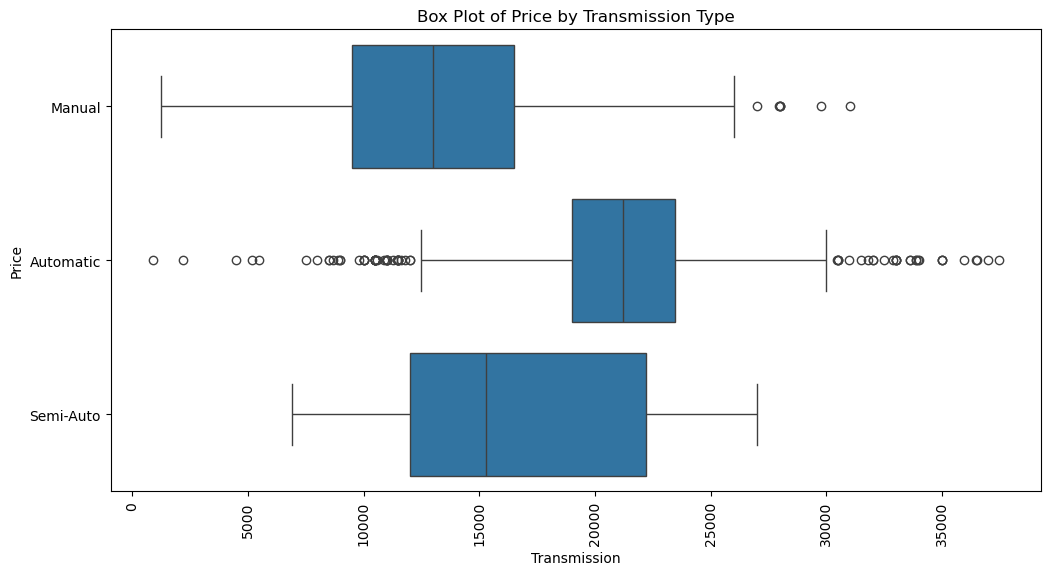

In [1122]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='price', y='transmission', data=df[:1000],orient='h')
plt.title('Box Plot of Price by Transmission Type')
plt.xlabel('Transmission')
plt.ylabel('Price')
plt.xticks(rotation=90) 
plt.show()

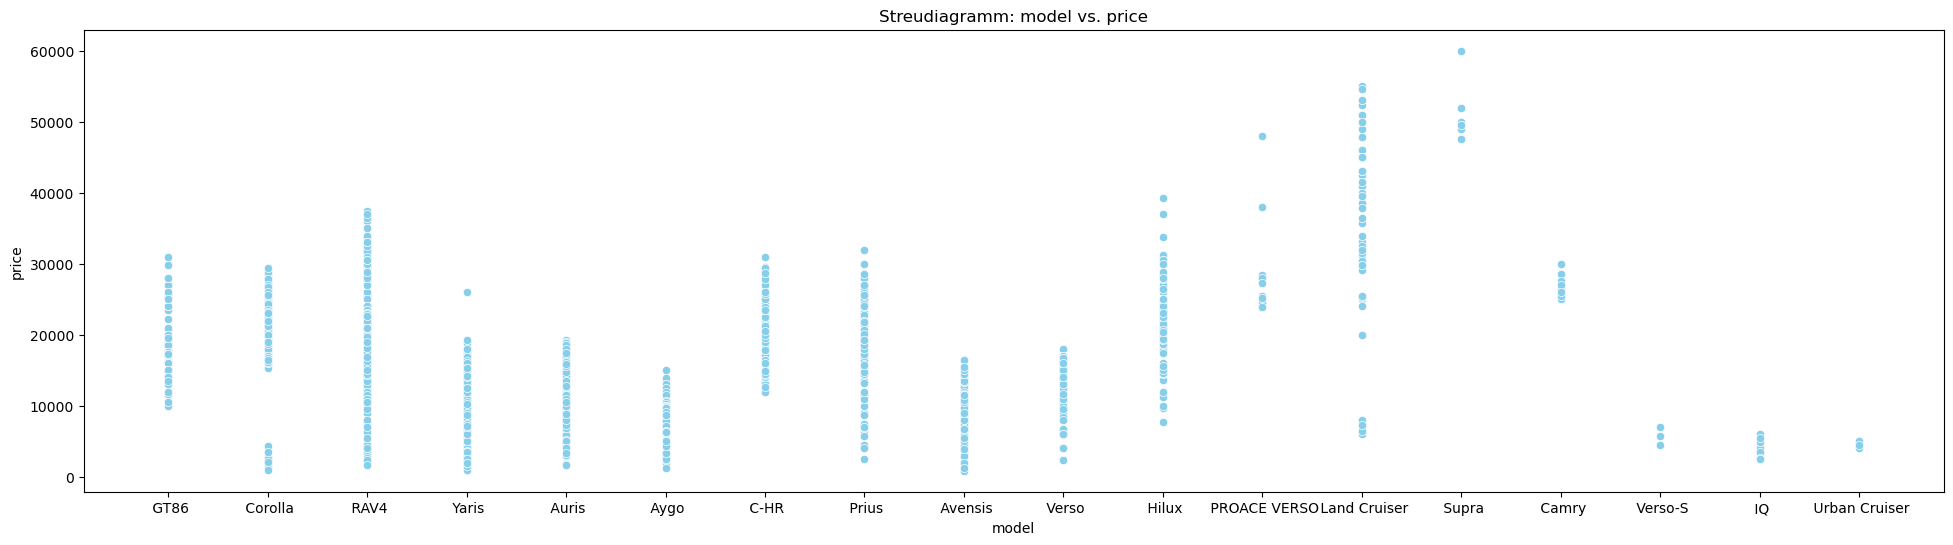

In [1123]:
import seaborn as sns

# Streudiagramm mit seaborn erstellen
plt.figure(figsize=(24, 6))
sns.scatterplot(data=df, x='model', y='price', color='skyblue')

# Titel hinzufügen
plt.title('Streudiagramm: model vs. price')

# Diagramm anzeigen
plt.show()

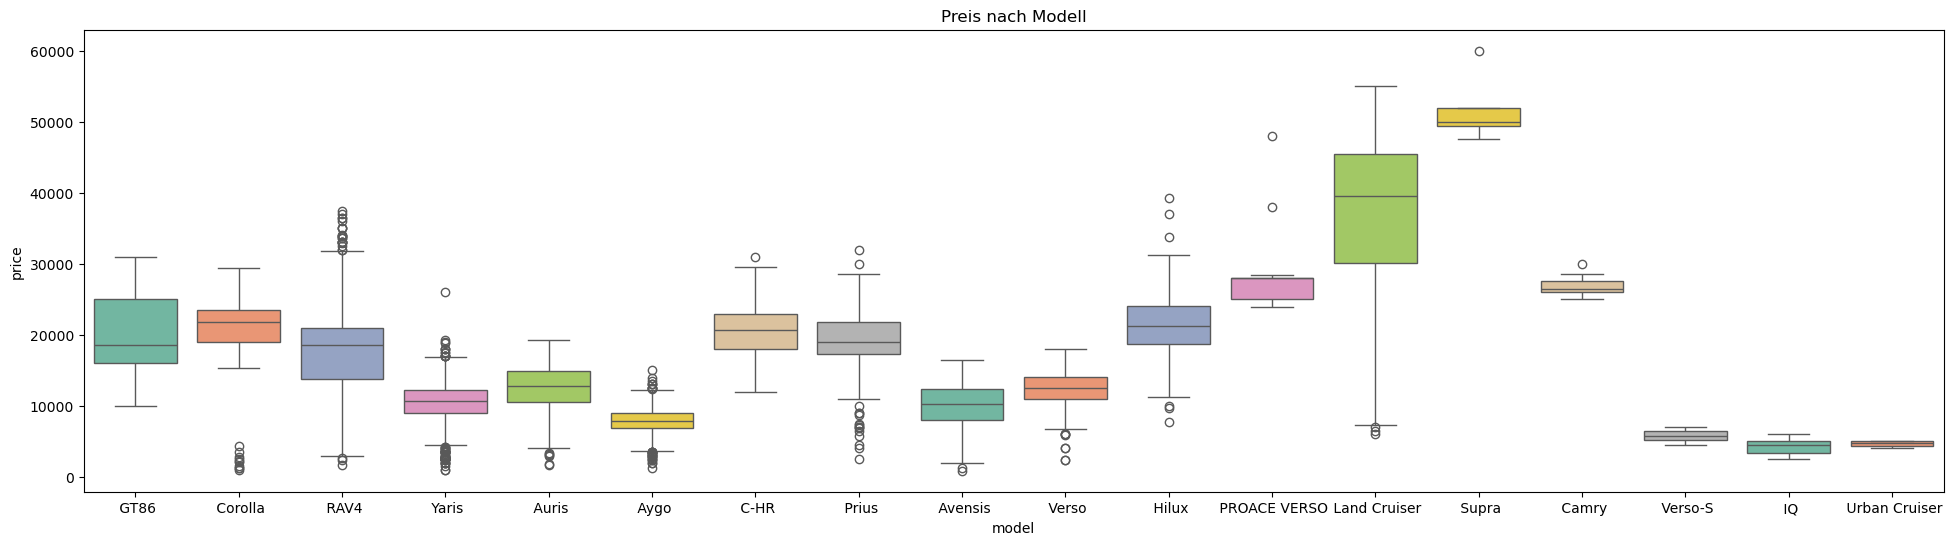

In [1124]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot erstellen mit hue anstelle von palette
plt.figure(figsize=(24, 6))
sns.boxplot(x='model', y='price', data=df, hue='model', palette='Set2', legend=False)

# Titel hinzufügen
plt.title('Preis nach Modell')

# Diagramm anzeigen
plt.show()

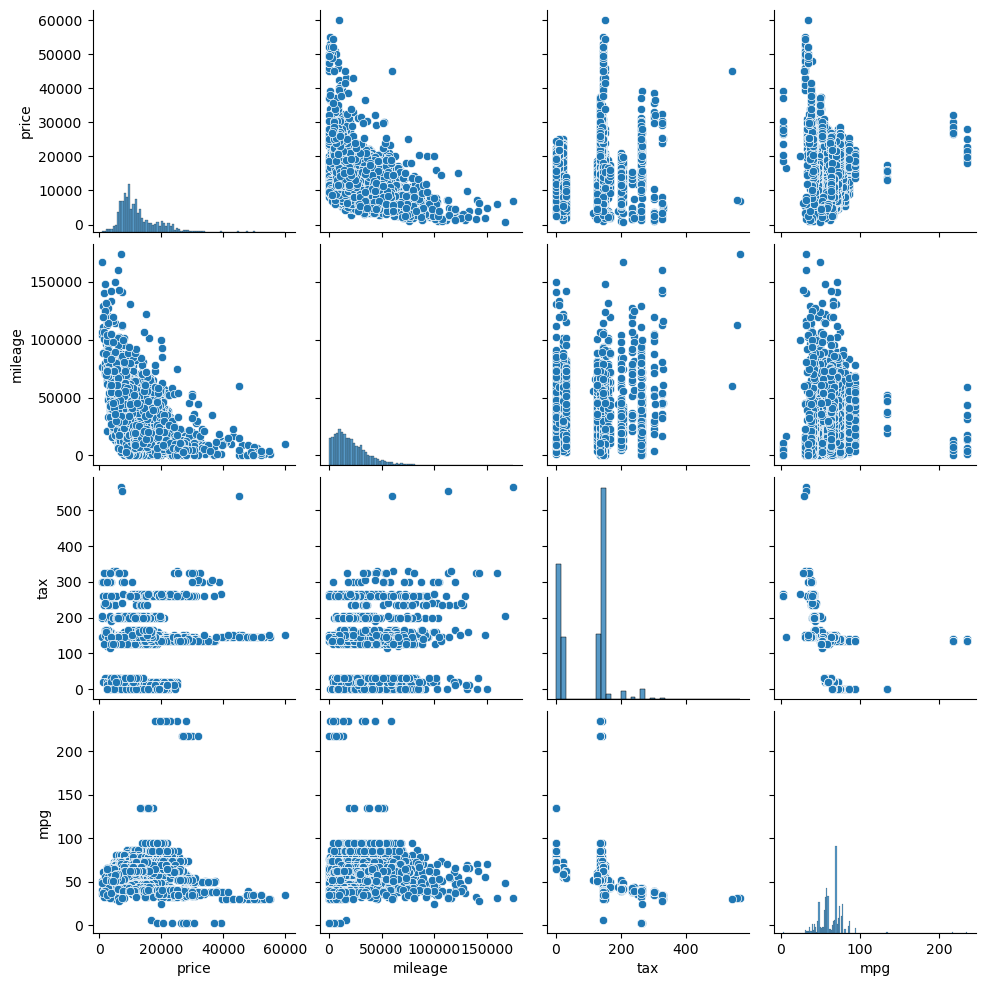

In [1125]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pairplot für price und mileage
sns.pairplot(df[['price', 'mileage', 'tax', 'transmission', 'mpg']])

# Diagramm anzeigen
plt.show()

### 2.4 Verifizierung der Datenqualität

In [1126]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [1127]:
# how many total missing values do we have?
total_cells = np.prod(df.shape)
total_missing = df.isnull().sum()

# percent of data that is missing
percent_missing = (total_missing/total_cells) * 100
print(percent_missing)

model           0.0
year            0.0
price           0.0
transmission    0.0
mileage         0.0
fuelType        0.0
tax             0.0
mpg             0.0
engineSize      0.0
dtype: float64


In [1128]:
df.dropna()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,GT86,2016,16000,Manual,24089,Petrol,265,36.2,2.0
1,GT86,2017,15995,Manual,18615,Petrol,145,36.2,2.0
2,GT86,2015,13998,Manual,27469,Petrol,265,36.2,2.0
3,GT86,2017,18998,Manual,14736,Petrol,150,36.2,2.0
4,GT86,2017,17498,Manual,36284,Petrol,145,36.2,2.0
...,...,...,...,...,...,...,...,...,...
6733,IQ,2011,5500,Automatic,30000,Petrol,20,58.9,1.0
6734,Urban Cruiser,2011,4985,Manual,36154,Petrol,125,50.4,1.3
6735,Urban Cruiser,2012,4995,Manual,46000,Diesel,125,57.6,1.4
6736,Urban Cruiser,2011,3995,Manual,60700,Petrol,125,50.4,1.3


In [1129]:
columns_with_na_dropped = df.dropna(axis=1)
columns_with_na_dropped.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,GT86,2016,16000,Manual,24089,Petrol,265,36.2,2.0
1,GT86,2017,15995,Manual,18615,Petrol,145,36.2,2.0
2,GT86,2015,13998,Manual,27469,Petrol,265,36.2,2.0
3,GT86,2017,18998,Manual,14736,Petrol,150,36.2,2.0
4,GT86,2017,17498,Manual,36284,Petrol,145,36.2,2.0


In [1130]:
# just how much data did we lose?
print("Columns in original dataset: %d \n" % df.shape[1])
print("Columns with na's dropped: %d" % columns_with_na_dropped.shape[1])

Columns in original dataset: 9 

Columns with na's dropped: 9


In [1131]:
df.fillna(0)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,GT86,2016,16000,Manual,24089,Petrol,265,36.2,2.0
1,GT86,2017,15995,Manual,18615,Petrol,145,36.2,2.0
2,GT86,2015,13998,Manual,27469,Petrol,265,36.2,2.0
3,GT86,2017,18998,Manual,14736,Petrol,150,36.2,2.0
4,GT86,2017,17498,Manual,36284,Petrol,145,36.2,2.0
...,...,...,...,...,...,...,...,...,...
6733,IQ,2011,5500,Automatic,30000,Petrol,20,58.9,1.0
6734,Urban Cruiser,2011,4985,Manual,36154,Petrol,125,50.4,1.3
6735,Urban Cruiser,2012,4995,Manual,46000,Diesel,125,57.6,1.4
6736,Urban Cruiser,2011,3995,Manual,60700,Petrol,125,50.4,1.3


In [1132]:
df.duplicated().sum()

39

In [1133]:
# Duplikate anzeigen (alle Spalten vergleichen)
duplikate = df[df.duplicated()]
print("Einfache Duplikate:")
print(duplikate)

Einfache Duplikate:
         model  year  price transmission  mileage fuelType  tax   mpg  \
178    Corolla  2019  17960       Manual     4500   Petrol  145  39.2   
286    Corolla  2019  15991       Manual       10   Petrol  145  39.2   
397       RAV4  2016  17495    Automatic    58100   Hybrid   20  55.4   
398       RAV4  2017  16295       Manual    34633   Diesel  125  60.1   
446       RAV4  2014  10999       Manual    57942   Diesel  145  53.0   
459       RAV4  2015  13500       Manual    45757   Diesel  125  57.6   
460       RAV4  2015  13500       Manual    45757   Diesel  125  57.6   
764       RAV4  2016  18795    Automatic    57000   Hybrid   20  55.4   
1178     Yaris  2016  10495    Automatic    33705   Hybrid    0  86.0   
1414     Yaris  2016   9495    Automatic    26191   Petrol   30  58.0   
1587     Yaris  2020  14769       Manual       25   Petrol  150  47.9   
1964     Yaris  2019  12495    Automatic     6000   Petrol  145  47.9   
2161     Yaris  2019  14495    

In [1134]:
# Duplikate inklusive des ersten Auftretens anzeigen
duplikate_mit_erstem = df[df.duplicated(keep=False)]
print("\nAlle Duplikate (inkl. erstes Vorkommen):")
print(duplikate_mit_erstem)


Alle Duplikate (inkl. erstes Vorkommen):
         model  year  price transmission  mileage fuelType  tax   mpg  \
177    Corolla  2019  17960       Manual     4500   Petrol  145  39.2   
178    Corolla  2019  17960       Manual     4500   Petrol  145  39.2   
285    Corolla  2019  15991       Manual       10   Petrol  145  39.2   
286    Corolla  2019  15991       Manual       10   Petrol  145  39.2   
344       RAV4  2015  13500       Manual    45757   Diesel  125  57.6   
...        ...   ...    ...          ...      ...      ...  ...   ...   
5560      Aygo  2019  10750       Manual       32   Petrol  145  57.7   
6356   Avensis  2017  10595       Manual    35939   Diesel  145  67.3   
6357   Avensis  2017  10595       Manual    35939   Diesel  145  67.3   
6569     Hilux  2015  14995    Automatic    72100   Diesel  260  32.8   
6570     Hilux  2015  14995    Automatic    72100   Diesel  260  32.8   

      engineSize  
177          1.2  
178          1.2  
285          1.2  
286  

In [1135]:
df_cleaned = df.drop_duplicates()

---
## 3 - Data Preparation (Datenaufbereitung)
- Auswahl der Daten
- Bereinigung der Daten
- Transformation und Integration der Daten
- Datenformatierung
- ---

### 3.1 Auswahl der Daten

In [1136]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

### 3.2 Bereinigung der Daten

In [1137]:
df.duplicated().sum()

39

In [1138]:
df_cleaned = df.drop_duplicates()

In [1139]:
df_cleaned.duplicated().sum()

0

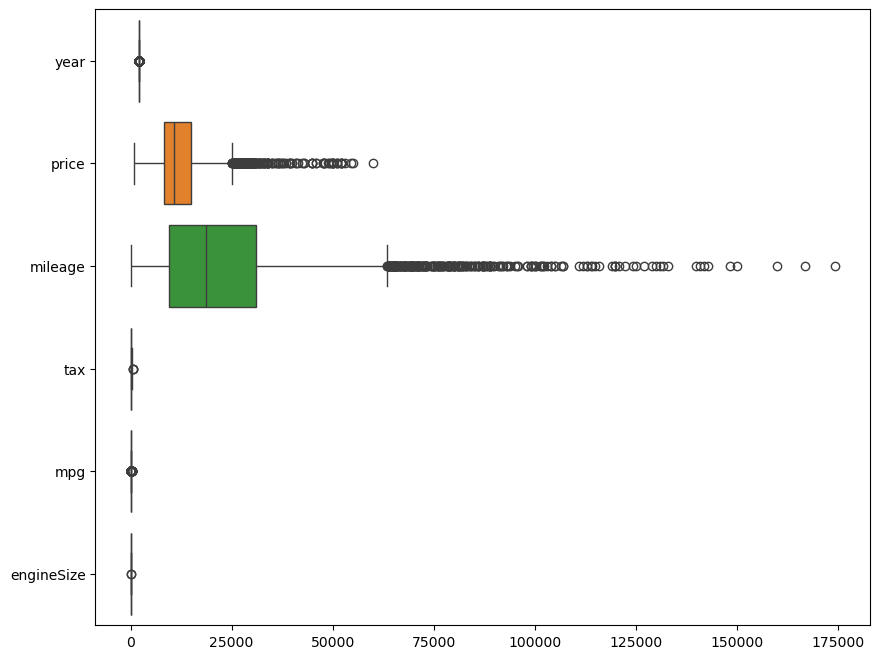

In [1140]:
plt.figure(figsize=(10,8))
sns.boxplot(data=df_cleaned,orient='h')
plt.show()

In [1141]:
import pandas as pd

# Nur numerische Spalten auswählen
num_cols = df.select_dtypes(include='number').columns

# Kopie für Bereinigung
df_clean = df.copy()

# Zeilen-Indexe mit Ausreißern sammeln
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter anwenden – nur Werte innerhalb der Grenzen behalten
    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

print(df_clean)


              model  year  price transmission  mileage fuelType  tax   mpg  \
0              GT86  2016  16000       Manual    24089   Petrol  265  36.2   
1              GT86  2017  15995       Manual    18615   Petrol  145  36.2   
2              GT86  2015  13998       Manual    27469   Petrol  265  36.2   
3              GT86  2017  18998       Manual    14736   Petrol  150  36.2   
4              GT86  2017  17498       Manual    36284   Petrol  145  36.2   
...             ...   ...    ...          ...      ...      ...  ...   ...   
6644   PROACE VERSO  2019  24450       Manual     9441   Diesel  145  40.4   
6645   PROACE VERSO  2019  23950       Manual     6570   Diesel  145  40.4   
6714          Camry  2019  24990    Automatic     5145   Hybrid  135  52.3   
6723        Verso-S  2013   6995       Manual    33900   Petrol  125  51.4   
6730             IQ  2013   4849       Manual    41142   Petrol    0  64.2   

      engineSize  
0            2.0  
1            2.0  
2     

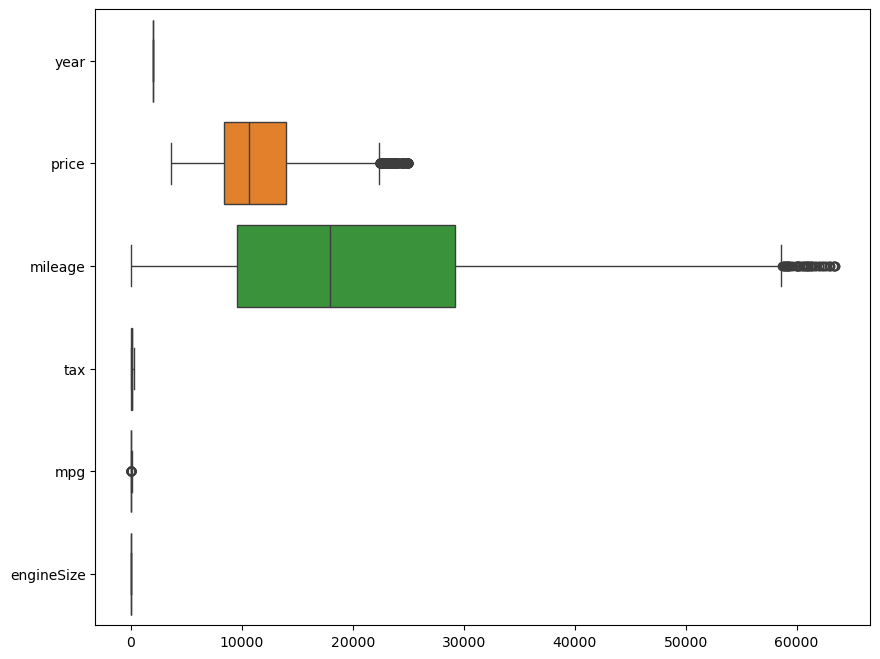

In [1142]:
plt.figure(figsize=(10,8))
sns.boxplot(data=df_clean,orient='h')
plt.show()

### Label Encoding

In [1143]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

col=['model','transmission','fuelType']
df_clean[col]=df_clean[col].apply(le.fit_transform)
df_clean.head(n=5)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,6,2016,16000,1,24089,3,265,36.2,2.0
1,6,2017,15995,1,18615,3,145,36.2,2.0
2,6,2015,13998,1,27469,3,265,36.2,2.0
3,6,2017,18998,1,14736,3,150,36.2,2.0
4,6,2017,17498,1,36284,3,145,36.2,2.0


In [1144]:
#df['price_group'] = pd.qcut(df['price'], q=3, labels=['jung', 'mittel', 'alt'])
df_clean['price_group'] = pd.qcut(df_clean['price'], q=3, labels=[1, 2, 3])

print (df_clean['price_group'])

0       3
1       3
2       3
3       3
4       3
       ..
6644    3
6645    3
6714    3
6723    1
6730    1
Name: price_group, Length: 6015, dtype: category
Categories (3, int64): [1 < 2 < 3]


In [1145]:
df_clean.price_group.describe()

count     6015
unique       3
top          1
freq      2010
Name: price_group, dtype: int64

### 3.3  Transformation und Integration der Daten

In [1146]:
df_encoded = pd.get_dummies(df_clean[['model', 'year', 'transmission', 'mileage', 'fuelType']])

print (df_encoded)

      model  year  transmission  mileage  fuelType
0         6  2016             1    24089         3
1         6  2017             1    18615         3
2         6  2015             1    27469         3
3         6  2017             1    14736         3
4         6  2017             1    36284         3
...     ...   ...           ...      ...       ...
6644      9  2019             1     9441         0
6645      9  2019             1     6570         0
6714      4  2019             0     5145         1
6723     13  2013             1    33900         3
6730      8  2013             1    41142         3

[6015 rows x 5 columns]


In [1147]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6015 entries, 0 to 6730
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   model         6015 non-null   int32
 1   year          6015 non-null   int64
 2   transmission  6015 non-null   int32
 3   mileage       6015 non-null   int64
 4   fuelType      6015 non-null   int32
dtypes: int32(3), int64(2)
memory usage: 211.5 KB


### 3.4 Datenformatierung

---
## 4 - Modeling (Modellierung)
- Auswahl des Modells
- Testmodell erstellen
- Modell erstellen
- ---

### 4.1  Auswahl des Modells

### 4.2 Testmodell erstellen

### 4.3 Modell erstellen

In [1148]:
from sklearn.tree import DecisionTreeRegressor
#from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

y = df_clean.price_group
features = ['model', 'year', 'transmission', 'mileage', 'fuelType']
X = df_encoded[features]

model = DecisionTreeRegressor(max_leaf_nodes=32, random_state=1)
model.fit(X, y)


DecisionTreeRegressor(max_leaf_nodes=32, random_state=1)

In [1149]:
model.predict(X)

array([2.98322148, 2.98322148, 2.28947368, ..., 2.98429833, 1.10787172,
       2.28947368])

In [1150]:
model.score(X, y)

0.8403476330751566

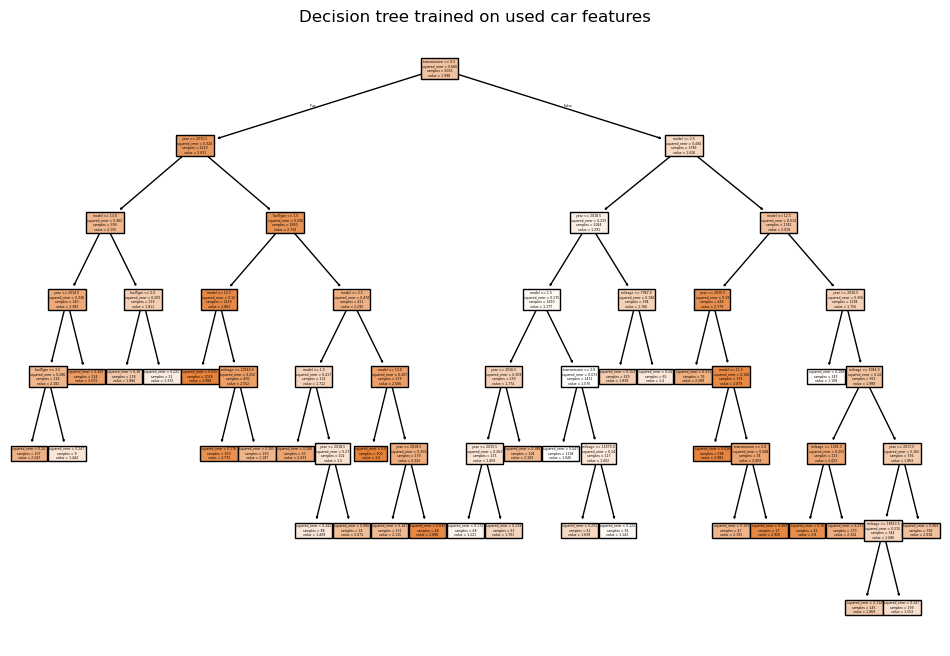

In [1151]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plot_tree(model, filled=True, feature_names=features , class_names=df_clean.price_group)
#plot_tree(model, filled=True, feature_names=features, class_names=df_clean.price)
plt.title("Decision tree trained on used car features")
plt.show()


In [1152]:
df_encoded.describe().T

,count,mean,std,min,25%,50%,75%,max
model,6015.0,6.948628,5.763103,0.0,2.0,3.0,14.0,14.0
year,6015.0,2016.977889,1.544381,2013.0,2016.0,2017.0,2018.0,2020.0
transmission,6015.0,0.699418,0.648160,0.0,0.0,1.0,1.0,3.0
mileage,6015.0,20461.048545,13907.002666,2.0,9597.5,17915.0,29228.0,63475.0
fuelType,6015.0,2.243392,1.044701,0.0,1.0,3.0,3.0,3.0


In [1153]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
model,6015.0,6.948628,5.763103,0.0,2.0,3.0,14.0,14.0
year,6015.0,2016.977889,1.544381,2013.0,2016.0,2017.0,2018.0,2020.0
price,6015.0,11923.841729,4760.712588,3590.0,8395.0,10690.0,13998.0,25000.0
transmission,6015.0,0.699418,0.648160,0.0,0.0,1.0,1.0,3.0
mileage,6015.0,20461.048545,13907.002666,2.0,9597.5,17915.0,29228.0,63475.0
fuelType,6015.0,2.243392,1.044701,0.0,1.0,3.0,3.0,3.0
tax,6015.0,91.684123,70.606652,0.0,0.0,135.0,145.0,265.0
mpg,6015.0,63.175561,11.331399,36.2,56.5,65.7,69.0,86.0
engineSize,6015.0,1.418936,0.391821,0.0,1.0,1.5,1.8,3.0


In [1154]:
print("Making predictions for the following 5 cars:")
print(X.head())
print("The predictions are")
print(model.predict(X.head()))

Making predictions for the following 5 cars:
   model  year  transmission  mileage  fuelType
0      6  2016             1    24089         3
1      6  2017             1    18615         3
2      6  2015             1    27469         3
3      6  2017             1    14736         3
4      6  2017             1    36284         3
The predictions are
[2.98322148 2.98322148 2.28947368 2.98322148 2.98322148]


### Train Test Split

In [1155]:
from sklearn.tree import DecisionTreeRegressor
#from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

y = df_clean.price
features = ['model', 'year', 'transmission', 'mileage', 'fuelType']
X = df_encoded[features]

model = DecisionTreeRegressor(max_leaf_nodes=32, random_state=1)
model.fit(X, y)


DecisionTreeRegressor(max_leaf_nodes=32, random_state=1)

In [1156]:
model.predict(X)

array([14398.96551724, 16117.84745763, 14398.96551724, ...,
       22857.26923077,  6926.16216216, 11512.        ])

In [1157]:
model.score(X, y)

0.9255969028224694

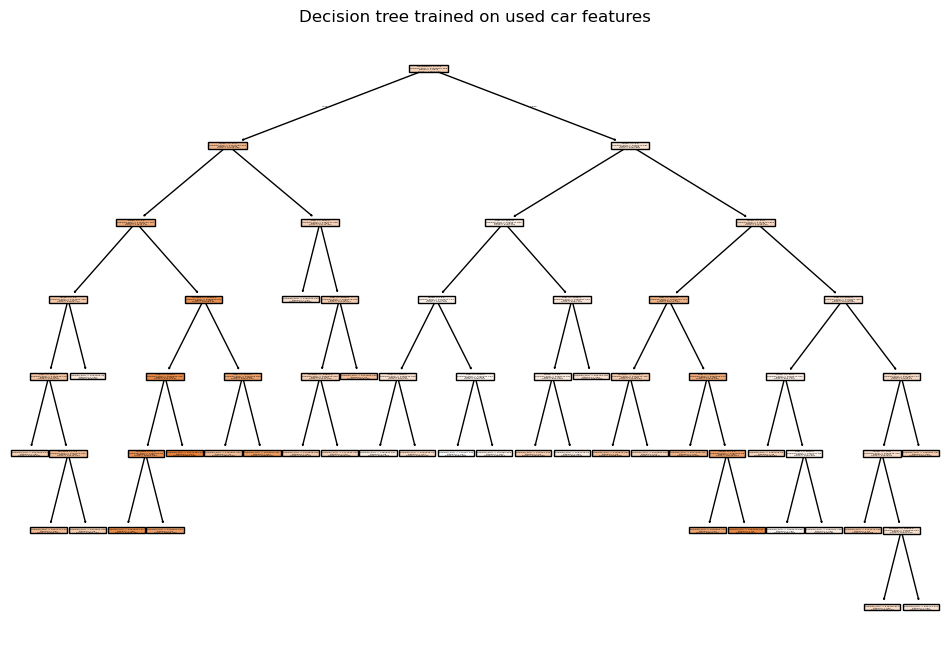

In [1158]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plot_tree(model, filled=True, feature_names=features , class_names=df_clean.price)
#plot_tree(model, filled=True, feature_names=features, class_names=df_clean.price)
plt.title("Decision tree trained on used car features")
plt.show()

In [1159]:
print("Making predictions for the following 5 cars:")
print(X.head())
print("The predictions are")
print(model.predict(X.head()))

Making predictions for the following 5 cars:
   model  year  transmission  mileage  fuelType
0      6  2016             1    24089         3
1      6  2017             1    18615         3
2      6  2015             1    27469         3
3      6  2017             1    14736         3
4      6  2017             1    36284         3
The predictions are
[14398.96551724 16117.84745763 14398.96551724 16117.84745763
 16117.84745763]


In [1160]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load the dataset

features = ['fuelType', 'model', 'year']#['model', 'year', 'transmission', 'mileage', 'fuelType']
X = df_encoded[features]
y = df_clean.price

# Split into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train the model
clf = DecisionTreeClassifier(max_depth=10, random_state=42)
clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = clf.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)

In [1161]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Ergebnisse anzeigen
print(f"📊 MAE:  {mae:.2f}")
print(f"📉 MSE:  {mse:.2f}")
print(f"📉 RMSE: {rmse:.2f}")
print(f"🧮 R²:   {r2:.2f}")

📊 MAE:  1105.20
📉 MSE:  2422488.62
📉 RMSE: 1556.43
🧮 R²:   0.89


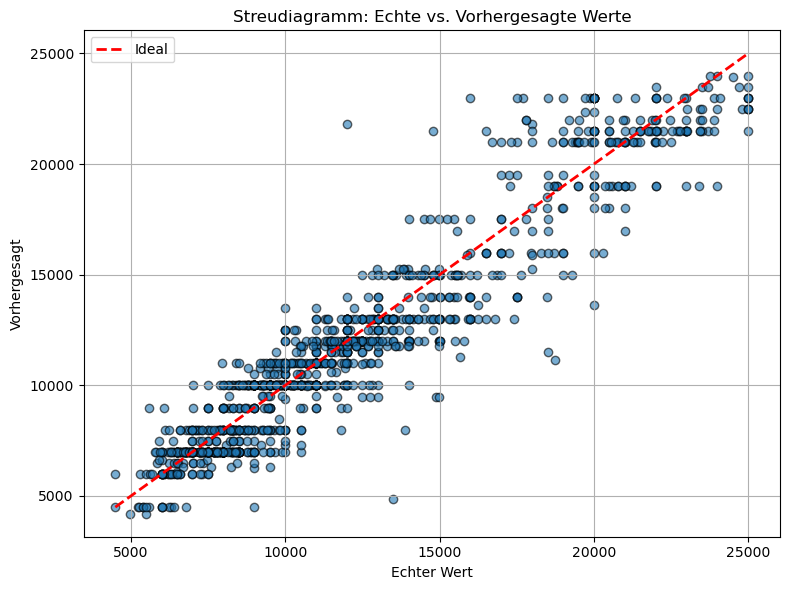

In [1162]:
import matplotlib.pyplot as plt

# Streudiagramm erstellen
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors="k")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', lw=2, label='Ideal')  # Linie y = x
plt.xlabel("Echter Wert")
plt.ylabel("Vorhergesagt")
plt.title("Streudiagramm: Echte vs. Vorhergesagte Werte")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 5 - Evaluation (Bewertung)
- Bewertung des Modells
- Bewertung der Resultate
- Bewertung des Prozesses
- Nächste Schritte festlegen

---

### 5.1 Bewertung des Modells

### 5.2 Bewertung der Resultate

### 5.3 Bewertung des Prozesses

### 5.4 Nächste Schritte festlegen

### Optional:_Vergleich mehrerer Modelle

In [1163]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

models = {
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_model = model.predict(X_test)
    r2 = r2_score(y_test, y_pred_model)
    #rmse = mean_squared_error(y_test, y_pred_model, squared=False)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    print(f"{name:>18} → R²: {r2:.3f} | RMSE: {rmse:.3f}")


     Decision Tree → R²: 0.882 | RMSE: 1556.435
     Random Forest → R²: 0.931 | RMSE: 1556.435
 Linear Regression → R²: 0.493 | RMSE: 1556.435


## 6 - Deployment (Anwendung)
- Zusammenfassender Bericht und Präsentation der Ergebnisse
- Implementierungs-strategie planen
- Überwachung der Gültigkeit der Modelle planen
- ---

In [1164]:
import pandas as pd

# DataFrame erstellen
results_df = pd.DataFrame({
    "Echter Wert": y_test,
    "Vorhergesagt": y_pred
})

# Optional: Differenz hinzufügen
results_df["Abweichung"] = results_df["Echter Wert"] - results_df["Vorhergesagt"]

# Die ersten Zeilen anzeigen
print(results_df.head(10))  # Zeigt 10 Beispiele
results_df.sort_values(by="Abweichung", key=abs, ascending=False)

      Echter Wert  Vorhergesagt  Abweichung
408         14490         13500         990
5226         6795          6995        -200
3386        11342         12495       -1153
5923        23991         22498        1493
122         20288         15990        4298
2283        10991         10995          -4
4280         5995          5995           0
5298         8800          6995        1805
3628        14995         14995           0
3399         9717         10795       -1078


,Echter Wert,Vorhergesagt,Abweichung
6313,12000,21790,-9790
658,13495,4849,8646
6218,18750,11160,7590
6168,18495,11495,7000
6104,15995,22995,-7000
...,...,...,...
4073,9995,9995,0
4283,9995,9995,0
5977,20995,20995,0
2012,10995,10995,0


In [1165]:
results_df.to_csv("vorhersagen.csv", index=False)